# Combien d'occupants, et qu'apportent température et humidité ?

Ce notebook prolonge `detection_occupation.ipynb`, qui a établi que le CO2
permet de détecter **si** une pièce est occupée. Deux questions restent
ouvertes :

1. **Peut-on estimer le nombre d'occupants ?** Deux personnes produisent deux
   fois plus de CO2 qu'une seule : l'information devrait être présente dans le
   signal. La difficulté n'est pas de distinguer 0 de 1 — c'est déjà acquis —
   mais **1 de 2**.

2. **Température et humidité aident-elles ?** La même sonde les mesure aux
   mêmes instants. L'humidité en particulier réagit à la présence humaine par
   un mécanisme distinct de celui du CO2 (respiration, transpiration), et
   pourrait donc apporter une information complémentaire.

La méthode reste celle validée précédemment : même construction du jeu de
données, même découpe par logement, mêmes garde-fous sur les valeurs manquantes.


## 1. Préparation des données


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'
SG_WINDOW, SG_POLY = 13, 2
IDN_EXTERIEUR = 90
hours = np.arange(144) / 6


In [2]:
# ── CO2 : dérivée sur la série continue, puis journées complètes
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR']).sort_values(['CODELIEU', 'DATE_HEURE'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()
co2['deriv'] = (co2.groupby('CODELIEU')['VALEUR']
                .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY, deriv=1, delta=1/6)))
n = co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2 = co2[n == 144].copy()
co2['tranche'] = co2.groupby(['CODELIEU', 'DATE']).cumcount()

print(f'{co2.groupby(["CODELIEU", "DATE"]).ngroups:,} journées CO2 complètes')


3,012 journées CO2 complètes


In [3]:
# ── Température et humidité : appareil QTR uniquement
# C'est la sonde qui mesure aussi le CO2 : les horodatages coïncident exactement,
# ce qui évite tout décalage entre grandeurs. Un second appareil (HYG) équipe une
# partie des logements ; le mélanger introduirait des mesures décalées.
def charger_qtr(fichier, nom):
    s = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/{fichier}', sep='\t',
                    encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR', 'APPAREIL'],
                    parse_dates=['DATE_HEURE'])
    s = s[s['APPAREIL'] == 'QTR'].copy()
    s['VALEUR'] = pd.to_numeric(s['VALEUR'], errors='coerce')
    s = s.dropna(subset=['VALEUR'])
    s['DATE'] = s['DATE_HEURE'].dt.normalize()
    s['tranche'] = s['DATE_HEURE'].dt.hour * 6 + s['DATE_HEURE'].dt.minute // 10
    # deux relevés peuvent tomber dans la même tranche de 10 min : on les moyenne
    return s.groupby(['CODELIEU', 'DATE', 'tranche'])['VALEUR'].mean().rename(nom).reset_index()

temp = charger_qtr('CNL1_SERIE_TPT.txt', 'temperature')
humi = charger_qtr('CNL1_SERIE_HRE.txt', 'humidite')

th = temp.merge(humi, on=['CODELIEU', 'DATE', 'tranche'], how='inner')

# Humidité ABSOLUE (g/m³) — l'humidité relative dépend de la température, ce qui
# masque l'effet de l'occupation. L'humidité absolue mesure la quantité réelle de
# vapeur d'eau, qui augmente directement avec la présence humaine.
T, RH = th['temperature'], th['humidite']
th['humidite_abs'] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674
                      / (273.15 + T))

print(f'{th.groupby(["CODELIEU", "DATE"]).ngroups:,} journées avec température ET humidité')
print(th[['temperature', 'humidite', 'humidite_abs']].describe().round(1).to_string())


4,142 journées avec température ET humidité
       temperature  humidite  humidite_abs
count     516736.0  516736.0      516736.0
mean          20.8      48.6           8.9
std            3.2      10.0           2.3
min            0.6      15.0           1.6
25%           19.0      41.7           7.3
50%           20.9      48.4           8.7
75%           22.8      55.4          10.4
max           38.9      90.4          18.2


In [4]:
# ── Semainier : position de chaque occupant, tranche par tranche
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')
sem = sem[sem['CODE_HEURE'].str.startswith('V_1')].copy()
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001

cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                   encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
sem['piece_capteur'] = sem['CODELIEU'].map(cap)

# Une déclaration manquante n'est pas une absence : on distingue les deux cas.
renseigne = sem['IDN_PIECE'].notna()
sem['dans_piece'] = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])

presence = (sem.groupby(['CODELIEU', 'DATE', 'tranche'])
            .agg(n_occupants=('dans_piece', 'sum'),
                 n_declares=('IDN_PIECE', 'size'),
                 n_renseignes=('IDN_PIECE', 'count'))
            .reset_index())
presence['n_manquants'] = presence['n_declares'] - presence['n_renseignes']

print(f'{presence.groupby(["CODELIEU", "DATE"]).ngroups:,} journées de semainier')


3,642 journées de semainier


In [5]:
# ── Croisement des trois sources
df = (co2[['CODELIEU', 'DATE', 'tranche', 'VALEUR', 'deriv']]
      .merge(th, on=['CODELIEU', 'DATE', 'tranche'], how='inner')
      .merge(presence, on=['CODELIEU', 'DATE', 'tranche'], how='inner'))

def bilan(d, etape):
    return {'étape': etape, 'observations': len(d),
            'journées': d.groupby(['CODELIEU', 'DATE']).ngroups,
            'logements': d['CODELIEU'].nunique()}

suivi = [bilan(df, 'CO2 × température/humidité × semainier')]

sat = df.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') >= 6000
df = df[~sat]
suivi.append(bilan(df, 'Sans journées saturées'))

# Semainier intégralement renseigné (voir detection_occupation.ipynb)
df = df[df['n_manquants'] == 0]
suivi.append(bilan(df, 'Semainier sans valeur manquante'))

df['heure'] = df['tranche'] / 6

# Cible : 0, 1 ou 2 occupants et plus (au-delà de 2, les effectifs sont marginaux)
df['n_occ'] = df['n_occupants'].clip(upper=2)

suivi = pd.DataFrame(suivi)
suivi['obs. perdues'] = -suivi['observations'].diff().fillna(0).astype(int)
display(suivi.set_index('étape'))

assert df[['VALEUR', 'deriv', 'temperature', 'humidite', 'humidite_abs']].notna().all().all()
print('Contrôle : aucune valeur manquante ✓')
print(f'\nJeu final : {len(df):,} observations · '
      f'{df.groupby(["CODELIEU", "DATE"]).ngroups:,} journées · '
      f'{df["CODELIEU"].nunique()} logements')
print('\nRépartition du nombre d\'occupants dans la pièce :')
rep = df['n_occ'].value_counts().sort_index()
for k, v in rep.items():
    lab = f'{k}' if k < 2 else '2 ou plus'
    print(f'  {lab:<10} {v:>8,}  ({100*v/len(df):5.1f}%)')


,observations,journées,logements,obs. perdues
étape,,,,
CO2 × température/humidité × semainier,389520,2705,469,0
Sans journées saturées,388224,2696,469,1296
Semainier sans valeur manquante,341042,2476,449,47182


Contrôle : aucune valeur manquante ✓

Jeu final : 341,042 observations · 2,476 journées · 449 logements

Répartition du nombre d'occupants dans la pièce :
  0           199,989  ( 58.6%)
  1            70,392  ( 20.6%)
  2 ou plus    70,661  ( 20.7%)


## 2. Estimer le nombre d'occupants

La question se dédouble :

- **0 contre au moins 1** — déjà traité dans le notebook précédent ;
- **1 contre 2 ou plus** — la vraie inconnue.

Ces deux tâches sont évaluées séparément. Confondre les deux donnerait un score
flatteur, porté par la première, sans montrer si la seconde fonctionne.


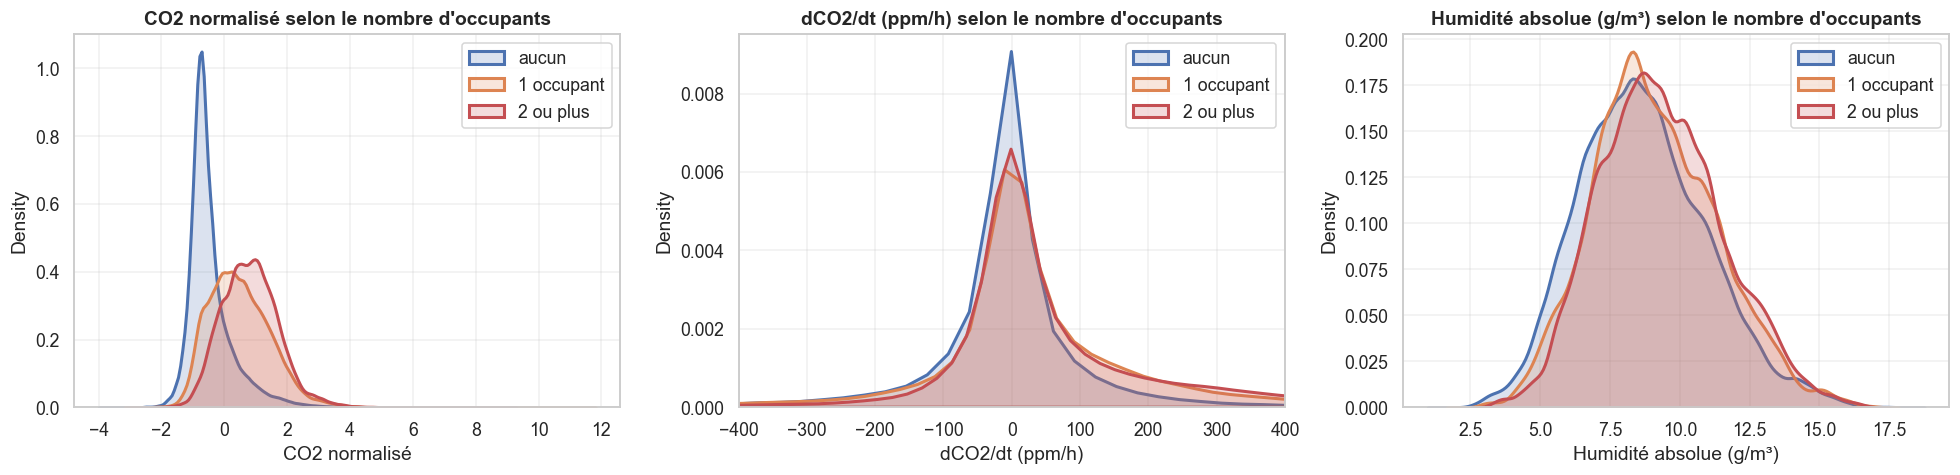

co2_znorm         deriv        temperature        humidite_abs       
           mean median   mean median        mean median         mean median
n_occ                                                                      
0         -0.45  -0.64 -24.42  -3.56       20.59   20.7         8.67   8.52
1          0.48   0.38  15.95   5.44       21.10   21.2         9.10   8.91
2          0.80   0.78  52.99  11.08       20.98   20.9         9.32   9.18

In [6]:
# Le signal se distingue-t-il selon le nombre d'occupants ?
stats_log = df.groupby('CODELIEU')['VALEUR'].agg(['mean', 'std'])
df['co2_znorm'] = ((df['VALEUR'] - df['CODELIEU'].map(stats_log['mean']))
                   / df['CODELIEU'].map(stats_log['std']).clip(lower=1e-9))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
labels = {0: 'aucun', 1: '1 occupant', 2: '2 ou plus'}

for ax, (col, titre) in zip(axes, [('co2_znorm', 'CO2 normalisé'),
                                   ('deriv', 'dCO2/dt (ppm/h)'),
                                   ('humidite_abs', 'Humidité absolue (g/m³)')]):
    for k, color in zip([0, 1, 2], ['#4C72B0', '#DD8452', '#C44E52']):
        sns.kdeplot(df.loc[df['n_occ'] == k, col], ax=ax, label=labels[k],
                    color=color, fill=True, alpha=0.2, lw=2)
    ax.set_xlabel(titre); ax.set_title(f'{titre} selon le nombre d\'occupants',
                                       fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
axes[1].set_xlim(-400, 400)

plt.tight_layout(); plt.show()

display(df.groupby('n_occ')[['co2_znorm', 'deriv', 'temperature', 'humidite_abs']]
        .agg(['mean', 'median']).round(2))


In [7]:
# ── Variables explicatives (identiques au notebook précédent, plus T et humidité)
d = df.sort_values(['CODELIEU', 'DATE', 'tranche']).copy()
g = d.groupby(['CODELIEU', 'DATE'])

d['deriv_lisse'] = g['deriv'].transform(
    lambda x: savgol_filter(x, SG_WINDOW, SG_POLY) if len(x) >= SG_WINDOW else x)
for w in (3, 6):
    d[f'co2_moy_{w*10}min'] = g['co2_znorm'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    d[f'deriv_moy_{w*10}min'] = g['deriv'].transform(lambda x: x.rolling(w, min_periods=1).mean())
d['co2_ecart_min'] = d['VALEUR'] - g['VALEUR'].transform('min')
d['heure_sin'] = np.sin(2 * np.pi * d['heure'] / 24)
d['heure_cos'] = np.cos(2 * np.pi * d['heure'] / 24)

# Température et humidité : niveau, écart au minimum du jour, et variation
for v in ('temperature', 'humidite_abs'):
    d[f'{v}_ecart_min'] = d[v] - g[v].transform('min')
    d[f'{v}_var30'] = g[v].transform(lambda x: x.diff(3).fillna(0))

F_CO2   = ['co2_znorm', 'deriv', 'deriv_lisse', 'co2_moy_30min', 'co2_moy_60min',
           'deriv_moy_30min', 'deriv_moy_60min', 'co2_ecart_min']
F_HEURE = ['heure_sin', 'heure_cos']
F_TH    = ['temperature', 'temperature_ecart_min', 'temperature_var30',
           'humidite_abs', 'humidite_abs_ecart_min', 'humidite_abs_var30']
FEATURES = F_CO2 + F_HEURE + F_TH

d = d.dropna(subset=FEATURES)
print(f'{len(d):,} observations · {len(FEATURES)} variables')
print(f'  CO2 : {len(F_CO2)} · heure : {len(F_HEURE)} · température/humidité : {len(F_TH)}')


341,042 observations · 16 variables
  CO2 : 8 · heure : 2 · température/humidité : 6


In [8]:
# ── Découpe par logement, puis deux tâches distinctes
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
itr, ite = next(gss.split(d, groups=d['CODELIEU']))
train, test = d.iloc[itr].copy(), d.iloc[ite].copy()
print(f'Entraînement : {len(train):,} obs · {train["CODELIEU"].nunique()} logements')
print(f'Test         : {len(test):,} obs · {test["CODELIEU"].nunique()} logements\n')

# Tâche 1 — présence : 0 contre au moins 1
m_pres = HistGradientBoostingClassifier(random_state=42).fit(
    train[FEATURES], (train['n_occ'] > 0).astype(int))
p_pres = m_pres.predict_proba(test[FEATURES])[:, 1]
auc_pres = roc_auc_score((test['n_occ'] > 0).astype(int), p_pres)
print(f'Tâche « présence » (0 vs ≥1)   : AUC = {auc_pres:.3f}')

# Tâche 2 — dénombrement : 1 contre 2 ou plus, UNIQUEMENT sur les tranches occupées.
# C'est la question nouvelle : sachant que la pièce est occupée, y a-t-il une ou
# plusieurs personnes ?
tr_occ = train[train['n_occ'] > 0]
te_occ = test[test['n_occ'] > 0]
y_tr = (tr_occ['n_occ'] == 2).astype(int)
y_te = (te_occ['n_occ'] == 2).astype(int)

m_nb = HistGradientBoostingClassifier(random_state=42).fit(tr_occ[FEATURES], y_tr)
p_nb = m_nb.predict_proba(te_occ[FEATURES])[:, 1]
auc_nb = roc_auc_score(y_te, p_nb)

print(f'Tâche « dénombrement » (1 vs ≥2) : AUC = {auc_nb:.3f}   '
      f'({len(te_occ):,} obs, dont {100*y_te.mean():.0f}% à 2+)')
print(f'  exactitude        : {accuracy_score(y_te, (p_nb >= 0.5).astype(int)):.3f}')
print(f'  exactitude équil. : {balanced_accuracy_score(y_te, (p_nb >= 0.5).astype(int)):.3f}')


Entraînement : 238,128 obs · 314 logements
Test         : 102,914 obs · 135 logements

Tâche « présence » (0 vs ≥1)   : AUC = 0.931
Tâche « dénombrement » (1 vs ≥2) : AUC = 0.654   (43,488 obs, dont 49% à 2+)
  exactitude        : 0.615
  exactitude équil. : 0.616


              precision    recall  f1-score   support

  1 occupant      0.642     0.569     0.603     22382
   2 ou plus      0.592     0.663     0.626     21106

    accuracy                          0.615     43488
   macro avg      0.617     0.616     0.614     43488
weighted avg      0.618     0.615     0.614     43488



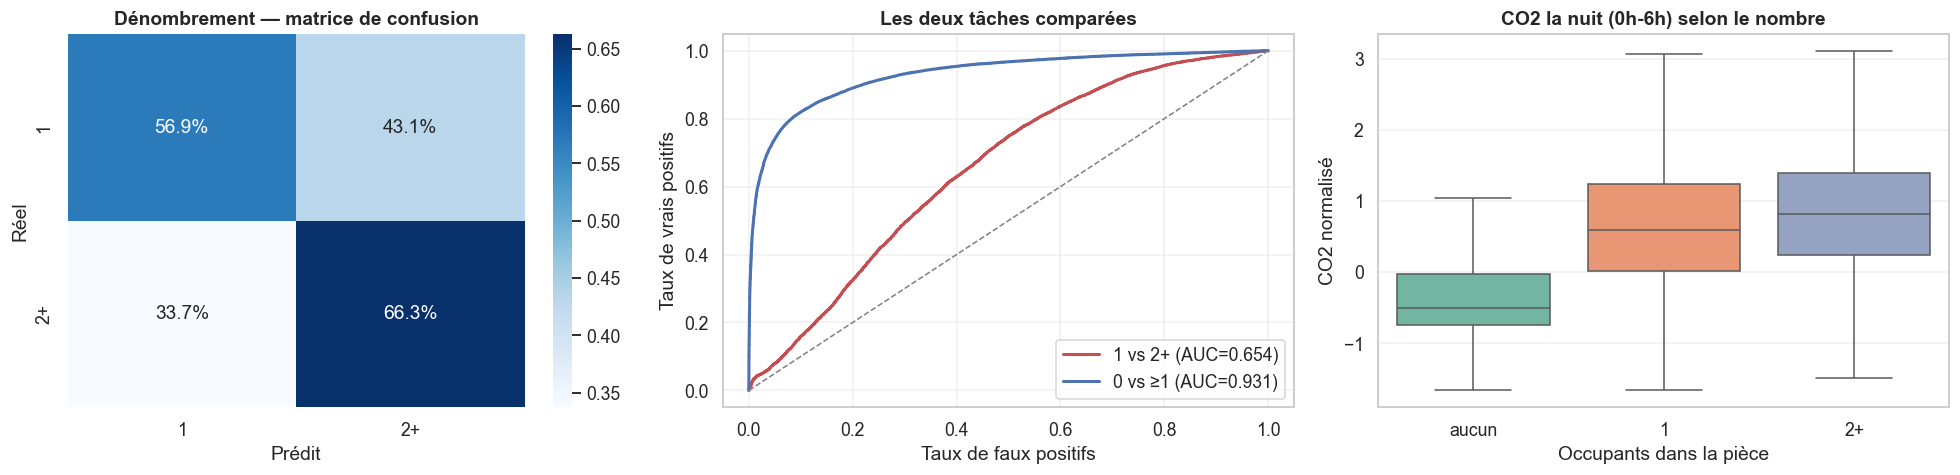

In [9]:
# ── Le dénombrement fonctionne-t-il vraiment ?
from sklearn.metrics import confusion_matrix, roc_curve, classification_report

print(classification_report(y_te, (p_nb >= 0.5).astype(int),
                            target_names=['1 occupant', '2 ou plus'], digits=3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

cm = confusion_matrix(y_te, (p_nb >= 0.5).astype(int), normalize='true')
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues', ax=axes[0],
            xticklabels=['1', '2+'], yticklabels=['1', '2+'])
axes[0].set_title('Dénombrement — matrice de confusion', fontweight='bold')
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')

fpr, tpr, _ = roc_curve(y_te, p_nb)
axes[1].plot(fpr, tpr, lw=2, color='#C44E52', label=f'1 vs 2+ (AUC={auc_nb:.3f})')
fpr2, tpr2, _ = roc_curve((test['n_occ'] > 0).astype(int), p_pres)
axes[1].plot(fpr2, tpr2, lw=2, color='#4C72B0', label=f'0 vs ≥1 (AUC={auc_pres:.3f})')
axes[1].plot([0, 1], [0, 1], color='grey', lw=1, ls='--')
axes[1].set_xlabel('Taux de faux positifs'); axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Les deux tâches comparées', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Le CO2 croît-il avec le nombre d'occupants, à heure comparable ?
nuit = df[(df['heure'] >= 0) & (df['heure'] < 6)]
sns.boxplot(data=nuit, x='n_occ', y='co2_znorm', ax=axes[2],
            hue='n_occ', palette='Set2', legend=False, showfliers=False)
axes[2].set_xticks([0, 1, 2]); axes[2].set_xticklabels(['aucun', '1', '2+'])
axes[2].set_xlabel('Occupants dans la pièce'); axes[2].set_ylabel('CO2 normalisé')
axes[2].set_title('CO2 la nuit (0h-6h) selon le nombre', fontweight='bold')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 3. Qu'apportent la température et l'humidité ?

Comparaison directe : le même modèle, entraîné avec puis sans ces variables,
sur les deux tâches. Toutes proviennent de la sonde QTR, celle qui mesure aussi
le CO2 — les mesures sont donc simultanées, sans décalage à corriger.


,nb,AUC présence,AUC dénombrement
variables,,,
CO2 + heure (référence),10,0.930,0.678
CO2 + heure + temp./humidité,16,0.931,0.654
Température/humidité seules,6,0.696,0.567
Humidité absolue seule,1,0.567,0.498
CO2 seul (sans heure),8,0.884,0.633


Apport de la température et de l'humidité :
  présence     : 0.930 → 0.931  (+0.001)
  dénombrement : 0.678 → 0.654  (-0.024)


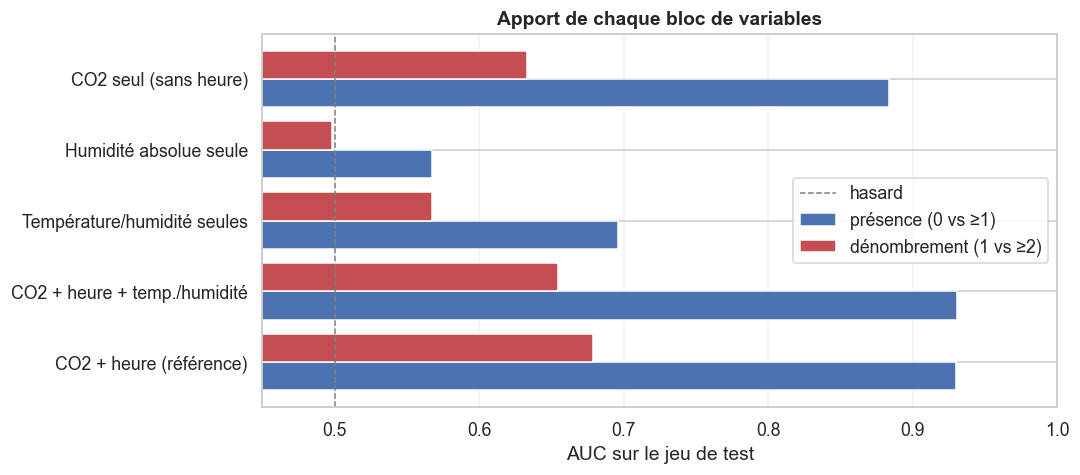

In [10]:
blocs = {
    'CO2 + heure (référence)':       F_CO2 + F_HEURE,
    'CO2 + heure + temp./humidité':  FEATURES,
    'Température/humidité seules':   F_TH,
    'Humidité absolue seule':        ['humidite_abs'],
    'CO2 seul (sans heure)':         F_CO2,
}

lignes = []
for nom, feats in blocs.items():
    m1 = HistGradientBoostingClassifier(random_state=42).fit(
        train[feats], (train['n_occ'] > 0).astype(int))
    a1 = roc_auc_score((test['n_occ'] > 0).astype(int),
                       m1.predict_proba(test[feats])[:, 1])
    m2 = HistGradientBoostingClassifier(random_state=42).fit(tr_occ[feats], y_tr)
    a2 = roc_auc_score(y_te, m2.predict_proba(te_occ[feats])[:, 1])
    lignes.append({'variables': nom, 'nb': len(feats),
                   'AUC présence': a1, 'AUC dénombrement': a2})

comp = pd.DataFrame(lignes).set_index('variables')
display(comp.round(3))

ref = comp.loc['CO2 + heure (référence)']
avec = comp.loc['CO2 + heure + temp./humidité']
print(f"Apport de la température et de l'humidité :")
print(f"  présence     : {ref['AUC présence']:.3f} → {avec['AUC présence']:.3f}  "
      f"({avec['AUC présence'] - ref['AUC présence']:+.3f})")
print(f"  dénombrement : {ref['AUC dénombrement']:.3f} → {avec['AUC dénombrement']:.3f}  "
      f"({avec['AUC dénombrement'] - ref['AUC dénombrement']:+.3f})")

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(comp))
ax.barh(x - 0.2, comp['AUC présence'], 0.4, label='présence (0 vs ≥1)', color='#4C72B0')
ax.barh(x + 0.2, comp['AUC dénombrement'], 0.4, label='dénombrement (1 vs ≥2)', color='#C44E52')
ax.axvline(0.5, color='grey', lw=1, ls='--', label='hasard')
ax.set_yticks(x); ax.set_yticklabels(comp.index)
ax.set_xlim(0.45, 1.0); ax.set_xlabel('AUC sur le jeu de test')
ax.set_title('Apport de chaque bloc de variables', fontweight='bold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


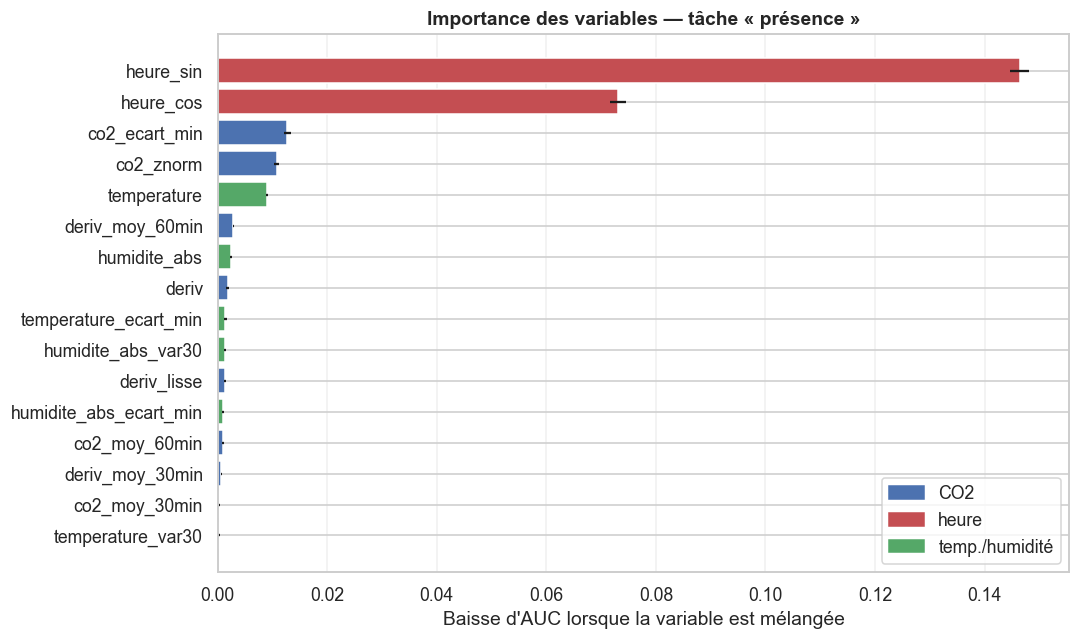

Importance cumulée par famille :
heure             0.2194
CO2               0.0315
temp./humidité    0.0155


In [11]:
# Quelles variables portent l'information, une fois toutes réunies ?
from sklearn.inspection import permutation_importance

sub = np.random.RandomState(42).choice(len(test), min(20_000, len(test)), replace=False)
imp = permutation_importance(m_pres, test[FEATURES].iloc[sub],
                             (test['n_occ'] > 0).astype(int).iloc[sub],
                             n_repeats=5, random_state=42, scoring='roc_auc')

familles = {**{f: 'CO2' for f in F_CO2}, **{f: 'heure' for f in F_HEURE},
            **{f: 'temp./humidité' for f in F_TH}}
couleurs = {'CO2': '#4C72B0', 'heure': '#C44E52', 'temp./humidité': '#55A868'}

ordre = np.argsort(imp.importances_mean)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([FEATURES[i] for i in ordre], imp.importances_mean[ordre],
        xerr=imp.importances_std[ordre],
        color=[couleurs[familles[FEATURES[i]]] for i in ordre])
ax.set_xlabel("Baisse d'AUC lorsque la variable est mélangée")
ax.set_title('Importance des variables — tâche « présence »', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=f) for f, c in couleurs.items()], loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

agg_imp = pd.Series(imp.importances_mean, index=FEATURES).groupby(familles).sum()
print('Importance cumulée par famille :')
print(agg_imp.sort_values(ascending=False).round(4).to_string())


## 4. Synthèse

### Le nombre d'occupants n'est que faiblement identifiable

| Tâche | AUC | Exactitude |
|---|---|---|
| Présence (0 contre ≥ 1) | **0.93** | 0.88 |
| Dénombrement (1 contre ≥ 2) | **0.65 – 0.68** | 0.62 |

Distinguer une personne de deux reste nettement au-dessus du hasard, mais très
loin de la fiabilité obtenue sur la présence. Les statistiques descriptives
expliquent pourquoi — le CO2 normalisé moyen vaut :

| Occupants | CO2 normalisé | dCO2/dt |
|---|---|---|
| aucun | −0.45 | −24 |
| 1 | +0.48 | +16 |
| 2 ou plus | +0.80 | +53 |

Le premier occupant fait bondir le CO2 (écart de 0.93), le second ne l'augmente
plus que de 0.32 — **trois fois moins**. Cet effet marginal décroissant est
attendu : le CO2 accumulé résulte d'un équilibre entre production et
renouvellement d'air, et il sature. À quoi s'ajoutent deux facteurs de confusion,
l'activité des occupants (dormir produit moins qu'être actif) et le taux de
ventilation propre au logement.

À noter : la dérivée passe de +16 à +53 entre un et deux occupants, soit un
facteur trois. C'est le signal le plus discriminant pour le dénombrement, alors
qu'il était secondaire pour la détection de présence.

### Température et humidité n'apportent rien

| Variables | AUC présence | AUC dénombrement |
|---|---|---|
| CO2 + heure | 0.930 | **0.678** |
| CO2 + heure + température/humidité | **0.931** | 0.654 |
| Température/humidité seules | 0.696 | 0.567 |
| Humidité absolue seule | 0.567 | 0.498 |

Le gain est nul sur la présence (+0.001) et **négatif sur le dénombrement**
(−0.024) : six variables supplémentaires sur une tâche déjà difficile ajoutent
du bruit plutôt que de l'information.

Prises isolément, ces grandeurs discriminent pourtant mieux que le hasard (0.696
pour la présence). Leur information est donc réelle mais **redondante** avec
celle du CO2 : les trois étant mesurées par la même sonde dans la même pièce,
elles réagissent aux mêmes causes. L'humidité absolue seule plafonne à 0.567,
loin des 0.849 du CO2 normalisé.

L'importance cumulée par famille confirme la hiérarchie :

| Famille | Importance |
|---|---|
| heure | 0.219 |
| CO2 | 0.032 |
| température/humidité | 0.016 |

### Ce qu'il faut en retenir

Le CO2 répond bien à « la pièce est-elle occupée ? », mal à « par combien de
personnes ? ». Ajouter température et humidité ne change rien — un résultat
négatif, mais utile : il ferme une piste et évite d'alourdir inutilement un
modèle.

Deux prolongements possibles si le dénombrement devait être approfondi :
concentrer l'analyse sur les phases de **montée** du CO2, où le débit de
production s'exprime le mieux, et normaliser par une estimation du taux de
renouvellement d'air propre à chaque logement, aujourd'hui confondu avec l'effet
du nombre d'occupants.
